preprocessing

In [1]:
from sklearn.preprocessing import MinMaxScaler,OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('laptopData.csv')
#drop unnecessary column
df.drop(columns='Unnamed: 0', inplace=True)
#clean string units and convert it to numeric 
df['Ram'] = df['Ram'].str.replace('GB', '', regex=False)
df['Weight'] = df['Weight'].str.replace('kg', '', regex=False)
df['Ram'] = pd.to_numeric(df['Ram'], errors='coerce')
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')
df['Inches'] = pd.to_numeric(df['Inches'], errors='coerce')
# drop the rows where the price is missing 
df.dropna(inplace=True)
# change type into category
cat_cols=['TypeName','ScreenResolution','Cpu','Memory','Gpu','OpSys']
df[cat_cols]=df[cat_cols].astype('category')

{'whiskers': [<matplotlib.lines.Line2D at 0x7fb481747750>,
 'caps': [<matplotlib.lines.Line2D at 0x7fb4817479d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fb481913610>],
 'medians': [<matplotlib.lines.Line2D at 0x7fb481747c50>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fb481747d90>],
 'means': []}

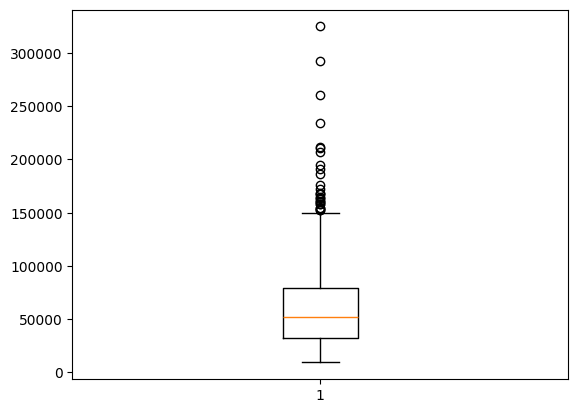

In [2]:
plt.boxplot(df['Price'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7fb481809450>,
 'caps': [<matplotlib.lines.Line2D at 0x7fb4818096d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fb481809310>],
 'medians': [<matplotlib.lines.Line2D at 0x7fb481809950>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fb481809a90>],
 'means': []}

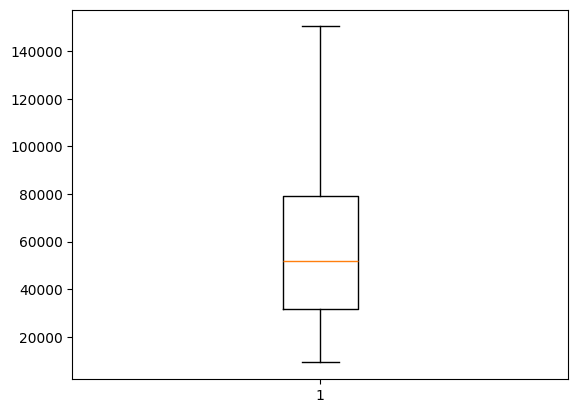

In [3]:

q25=df['Price'].quantile(.25)
q75=df['Price'].quantile(.75)
iqr=q75-q25
lower,upper=q25-1.5*iqr,q75+1.5*iqr
df['Price'] = np.where(df['Price'] > upper, upper, 
                       np.where(df['Price'] < lower, lower, df['Price']))
plt.boxplot(df['Price'])



In [4]:
df.isna().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [5]:
# split data for modeling
train,test=train_test_split(df,test_size=.2,random_state=42)

In [6]:
# scale numerical columns
num_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])
# encode and then scale categorical columns
cat_transformer = Pipeline(steps=[
    ('encoder', OrdinalEncoder()),
     ('scaler', MinMaxScaler())
])
num_col=df.select_dtypes(include=np.number).columns.tolist()
cat_col=df.select_dtypes(include='category').columns.tolist()

# It ensures that the numerical columns go through the num_transformer and categorical columns go through the cat_transformer simultaneously
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_col),
        ('cat', cat_transformer, cat_col)
    ])

# pipeline
main_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])


train_transformed = main_pipeline.fit_transform(train)
test_transformed = main_pipeline.fit_transform(test)
df_transformed=main_pipeline.fit_transform(df)

In [7]:
train_df=pd.DataFrame(train_transformed,columns=main_pipeline.get_feature_names_out())
test_df=pd.DataFrame(test_transformed,columns=main_pipeline.get_feature_names_out())
df_df=pd.DataFrame(df_transformed,columns=main_pipeline.get_feature_names_out())

In [8]:
def cols(df):
    df.columns=[(col.split('__'))[1].lower() for col in df.columns]
    return df

In [9]:
test_df.columns

Index(['num__Inches', 'num__Ram', 'num__Weight', 'num__Price', 'cat__TypeName',
       'cat__ScreenResolution', 'cat__Cpu', 'cat__Memory', 'cat__Gpu',
       'cat__OpSys'],
      dtype='object')

In [10]:
# normalize the columns names

def cols(df):
    df.columns=[(col.split('__'))[1].lower() for col in df.columns]
    return df

test_df=cols(test_df)
df_df=cols(df_df)
train_df=cols(train_df)

In [11]:
df_df.columns

Index(['inches', 'ram', 'weight', 'price', 'typename', 'screenresolution',
       'cpu', 'memory', 'gpu', 'opsys'],
      dtype='object')

In [12]:
train_df.isna().sum()

inches              0
ram                 0
weight              0
price               0
typename            0
screenresolution    0
cpu                 0
memory              0
gpu                 0
opsys               0
dtype: int64

ml view

(1016, 10)   (10, 1)   (1016, 1)
0.022511364293641742
[[-0.35263086]
 [-0.05379555]
 [ 0.87998508]
 [ 0.06997293]
 [ 0.02654515]
 [ 0.22254088]
 [ 0.30403412]
 [ 0.15998397]
 [ 0.18914874]
 [ 0.31863606]]


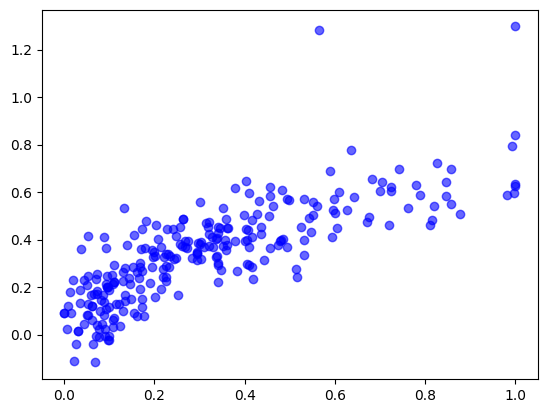

In [13]:
class LinearRegressionGD:
    def __init__(self):
        self.theta=None
        self.sse=float('inf')
        
    def fit(self,x,y,learningRate=.1,n_iter=1000,tolerance=1e-6,l_ridge=0,a_lasso=0):

        x=x.to_numpy()
        y=y.to_numpy().reshape(-1,1)

        self.theta=np.zeros((x.shape[1]+1,1))
        x=np.hstack((np.ones((len(x),1)),x))
        print(x.shape,' ',self.theta.shape,' ',y.shape)

        for _ in range(n_iter):
            gradient=2/len(x)* x.T @(x@self.theta -y)

            theta_reg=self.theta.copy()
            theta_reg[0]=0

            gradient+= (2 * l_ridge / len(x)) * theta_reg       
            gradient += (a_lasso / len(x)) * np.sign(theta_reg)
            
            self.theta-=learningRate*gradient

            n_sse=np.sum((y-(x @ self.theta))**2)
            if abs(self.sse - n_sse) < tolerance:
                self.sse = n_sse
                break
            self.sse = n_sse
        return self.theta
    
    def predict(self,x):
        if self.theta is None:
            raise ValueError('the model hasn\'t been fitted yet')

        x=x.to_numpy()
        x=np.hstack((np.ones((len(x),1)),x))
        return x @ self.theta
    
    def mse(self,yt,yp):
        yt=yt.to_numpy().reshape(-1,1)

        return 1/len(yt)*np.sum((yt-yp)**2)
    
    def plot(self,yt,yp):
        yt=yt.to_numpy().reshape(-1,1)

        plt.scatter(x=yt,y=yp,alpha=.6,color='blue')


l=LinearRegressionGD()

x=train_df.drop('price',axis=1)
y=train_df['price']

xt=test_df.drop('price',axis=1)
yt=test_df['price']

l.fit(x,y,learningRate=.1,n_iter=1000)
y_predicted=l.predict(xt)
print(l.mse(yt,y_predicted))
print(l.theta)
l.plot(yt,y_predicted)

numerical view

(1016,) (1016,)


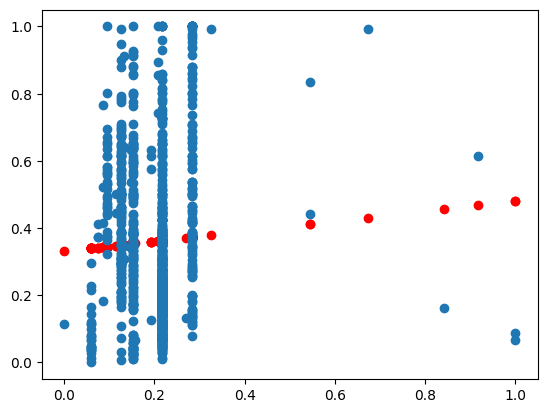

In [14]:
class SimpleLinearRegressionNumerical:
    
    def __init__(self):
        self.a0 = None       
        self.a1 = None         
        self.SSE = None        
        self.MSE = None        
        self.R2 = None        
        self.feature_name = None
        
    def _compute_sums(self, X, y):
        n = len(X)
        Sx = np.sum(X)
        Sy = np.sum(y)
        Sxx = np.sum(X**2)
        Sxy = np.sum(X * y)
        Syy = np.sum(y**2)
        return n, Sx, Sy, Sxx, Sxy, Syy
    
    def _soft_threshold(self, value, threshold):
        return np.sign(value) * max(0, abs(value) - threshold)
    
    def fit(self, X, y, ridge_lambda=0, lasso_lambda=0, show_steps=False, feature_name=None):
        

        X = np.asarray(X, dtype=float).flatten()
        y = np.asarray(y, dtype=float).flatten()
        self.feature_name = feature_name
        
        n, Sx, Sy, Sxx, Sxy, Syy = self._compute_sums(X, y)
        x_bar, y_bar = Sx/n, Sy/n
        
        if show_steps:
            print(f"=== Simple Linear Regression - Numerical View ===")
            print(f"Feature: {feature_name or 'X'} → Target: Price\n")
            print("Step 1: Define SSE")
            print("SSE = Σ(yi - a0 - a1*xi)²\n")
            print("Step 2: Compute Summations")
            print(f"n     = {n}")
            print(f"Σxi   = {Sx:.4f}")
            print(f"Σyi   = {Sy:.4f}")
            print(f"Σxi²  = {Sxx:.4f}")
            print(f"Σxiyi = {Sxy:.4f}\n")

        SXX = Sxx - n * x_bar**2  # Σ(xi - x̄)²
        SXY = Sxy - n * x_bar * y_bar  # Σ(xi - x̄)(yi - ȳ)

        if ridge_lambda > 0:
            ridge_penalty = n * ridge_lambda
            if show_steps:
                print(f"Step 3: Apply Ridge Penalty (λ={ridge_lambda})")
                print(f"Ridge penalty = n×λ = {n}×{ridge_lambda} = {ridge_penalty:.4f}")
                print(f"Modified denominator: SXX + nλ = {SXX:.4f} + {ridge_penalty:.4f} = {SXX + ridge_penalty:.4f}\n")
            SXX_ridge = SXX + ridge_penalty
        else:
            SXX_ridge = SXX

        if lasso_lambda > 0:
            lasso_penalty = n * lasso_lambda
            if show_steps:
                print(f"Step 3: Apply Lasso Penalty (λ={lasso_lambda})")
                print(f"Lasso penalty = n×λ = {n}×{lasso_lambda} = {lasso_penalty:.4f}")
                print(f"Soft-threshold: sign({SXY:.4f}) × max(0, |{SXY:.4f}| - {lasso_penalty:.4f})\n")
            SXY_lasso = self._soft_threshold(SXY, lasso_penalty)
        else:
            SXY_lasso = SXY

        if SXX_ridge == 0:
            self.a1 = 0 
        else:
            self.a1 = SXY_lasso / SXX_ridge
            
        self.a0 = y_bar - self.a1 * x_bar
        
        if show_steps:
            print("Step 4: Solve for Coefficients")
            print(f"a1 (slope) = {SXY_lasso:.4f} / {SXX_ridge:.4f} = {self.a1:.4f}")
            print(f"a0 (intercept) = ȳ - a1×x̄ = {y_bar:.4f} - {self.a1:.4f}×{x_bar:.4f} = {self.a0:.4f}\n")

        y_hat = self.predict(X)
        residuals = y - y_hat
        self.SSE = np.sum(residuals**2)
        self.MSE = self.SSE / n
        
        # R² = 1 - SSE/SST
        SST = Syy - n * y_bar**2
        self.R2 = 1 - (self.SSE / SST) if SST > 0 else 0
        
        if show_steps:
            print("Final Model:")
            print(f"ŷ = {self.a0:.4f} + {self.a1:.4f} × {feature_name or 'X'}")
            print(f"SSE = {self.SSE:.4f}")
            print(f"MSE = {self.MSE:.4f}")
            print(f"R²  = {self.R2:.4f}")
        
        return self
    
    def predict(self, X):
    
        if self.a0 is None or self.a1 is None:
            raise ValueError("Model not fitted yet. Call fit() first.")
        X = np.asarray(X, dtype=float).flatten()
        return self.a0 + self.a1 * X
    
    def plot(self, X, y, title=None):
     
        if self.a0 is None or self.a1 is None:
            raise ValueError("Model not fitted yet.")
        
        X = np.asarray(X).flatten()
        y = np.asarray(y).flatten()
        y_pred = self.predict(X)
        
       
        sort_idx = np.argsort(X)
        X_sorted, y_pred_sorted = X[sort_idx], y_pred[sort_idx]
        
        plt.figure(figsize=(8, 6))
        plt.scatter(X, y, alpha=0.6, color='steelblue', label='Actual Data', edgecolors='white')
        plt.plot(X_sorted, y_pred_sorted, color='crimson', lw=2.5, label='Fitted Line')
        
   
        eq_text = f"ŷ = {self.a0:.2f} + {self.a1:.2f}×{self.feature_name or 'X'}\nR² = {self.R2:.3f}"
        plt.text(0.05, 0.95, eq_text, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
        
        plt.xlabel(self.feature_name or 'X')
        plt.ylabel('Price')
        plt.title(title or f"Simple Linear Regression - Numerical View")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# test the model

x=train_df['inches']
y=train_df['price']
m=SimpleLinearRegressionNumerical()
print(x.shape,y.shape)
m.fit(x,y)
yp=m.predict(x)
plt.scatter(x,yp,c='r')
plt.scatter(x,y)

In [15]:
df.columns

Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')

statistics view

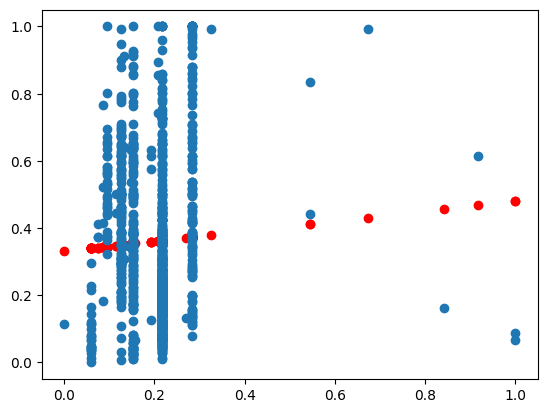

In [16]:
import numpy as np

try:
    from scipy import stats
except Exception:
    stats = None


class SimpleLinearRegressionStatistical:
    """
    Statistical-view Simple Linear Regression with optional Ridge/Lasso regularization.

    Notes:
    - Exact inference (SE, t, p, CI) is valid for OLS.
    - For Ridge/Lasso, the inference values here are approximate for comparison use.
    """

    def __init__(self):
        self.a0 = None
        self.a1 = None
        self.feature_name = None

        self.n = None
        self.df_resid = None
        self.sxx = None
        self.sxy = None

        self.SSE = None
        self.MSE = None
        self.R2 = None
        self.adjusted_R2 = None

        self.se_a0 = None
        self.se_a1 = None
        self.t_a0 = None
        self.t_a1 = None
        self.p_a0 = None
        self.p_a1 = None
        self.ci_a0 = (None, None)
        self.ci_a1 = (None, None)

        self.ridge_lambda = 0.0
        self.lasso_lambda = 0.0

    @staticmethod
    def _soft_threshold(value, threshold):
        return np.sign(value) * max(0.0, abs(value) - threshold)

    def fit(self, X, y, ridge_lambda=0.0, lasso_lambda=0.0, feature_name="X"):
        X = np.asarray(X, dtype=float).flatten()
        y = np.asarray(y, dtype=float).flatten()

        if X.shape[0] != y.shape[0]:
            raise ValueError("X and y must have the same length.")
        if X.shape[0] < 3:
            raise ValueError("Need at least 3 samples for statistical inference.")

        self.feature_name = feature_name
        self.ridge_lambda = float(ridge_lambda)
        self.lasso_lambda = float(lasso_lambda)

        self.n = X.shape[0]
        self.df_resid = self.n - 2

        x_bar = X.mean()
        y_bar = y.mean()

        self.sxx = np.sum((X - x_bar) ** 2)
        self.sxy = np.sum((X - x_bar) * (y - y_bar))

        denom = self.sxx + self.n * self.ridge_lambda if self.ridge_lambda > 0 else self.sxx
        numer = self._soft_threshold(self.sxy, self.n * self.lasso_lambda) if self.lasso_lambda > 0 else self.sxy

        self.a1 = 0.0 if denom == 0 else numer / denom
        self.a0 = y_bar - self.a1 * x_bar

        y_hat = self.predict(X)
        residuals = y - y_hat

        self.SSE = float(np.sum(residuals ** 2))
        self.MSE = float(self.SSE / self.df_resid)

        sst = float(np.sum((y - y_bar) ** 2))
        self.R2 = 1.0 - (self.SSE / sst) if sst > 0 else 0.0
        self.adjusted_R2 = 1.0 - (1.0 - self.R2) * (self.n - 1) / self.df_resid

        sigma2 = self.MSE
        if self.sxx <= 0:
            self.se_a1 = np.inf
            self.se_a0 = np.inf
        else:
            self.se_a1 = float(np.sqrt(sigma2 / self.sxx))
            self.se_a0 = float(np.sqrt(sigma2 * (1.0 / self.n + (x_bar ** 2) / self.sxx)))

        self.t_a1 = np.nan if not np.isfinite(self.se_a1) or self.se_a1 == 0 else float(self.a1 / self.se_a1)
        self.t_a0 = np.nan if not np.isfinite(self.se_a0) or self.se_a0 == 0 else float(self.a0 / self.se_a0)

        if stats is not None and self.df_resid > 0:
            self.p_a1 = float(2.0 * stats.t.sf(abs(self.t_a1), self.df_resid)) if np.isfinite(self.t_a1) else np.nan
            self.p_a0 = float(2.0 * stats.t.sf(abs(self.t_a0), self.df_resid)) if np.isfinite(self.t_a0) else np.nan
            t_crit = float(stats.t.ppf(0.975, self.df_resid))

            self.ci_a1 = (self.a1 - t_crit * self.se_a1, self.a1 + t_crit * self.se_a1)
            self.ci_a0 = (self.a0 - t_crit * self.se_a0, self.a0 + t_crit * self.se_a0)
        else:
            self.p_a1 = np.nan
            self.p_a0 = np.nan
            self.ci_a1 = (np.nan, np.nan)
            self.ci_a0 = (np.nan, np.nan)

        return self

    def predict(self, X):
        if self.a0 is None or self.a1 is None:
            raise ValueError("Model not fitted yet. Call fit() first.")
        X = np.asarray(X, dtype=float).flatten()
        return self.a0 + self.a1 * X

    def evaluate(self, X, y, predictors_count=1):
        X = np.asarray(X, dtype=float).flatten()
        y = np.asarray(y, dtype=float).flatten()
        y_hat = self.predict(X)

        sse = float(np.sum((y - y_hat) ** 2))
        mse = float(np.mean((y - y_hat) ** 2))
        rmse = float(np.sqrt(mse))

        y_bar = float(np.mean(y))
        sst = float(np.sum((y - y_bar) ** 2))
        r2 = 1.0 - (sse / sst) if sst > 0 else 0.0

        n = len(y)
        k = int(predictors_count)
        if n > (k + 1):
            adjusted_r2 = 1.0 - (1.0 - r2) * (n - 1) / (n - k - 1)
        else:
            adjusted_r2 = np.nan

        return {
            "SSE": sse,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2,
            "Adjusted_R2": adjusted_r2,
            "Predictors": k,
        }

    def summary(self):
        print("=" * 72)
        print("Simple Linear Regression - Statistical View")
        print("=" * 72)
        print(f"Feature: {self.feature_name}")
        print(f"n = {self.n}, df_resid = {self.df_resid}")
        print(f"Regularization: ridge_lambda={self.ridge_lambda}, lasso_lambda={self.lasso_lambda}")
        print("-" * 72)
        print(f"Model: y_hat = {self.a0:.6f} + {self.a1:.6f} * {self.feature_name}")
        print(f"SSE = {self.SSE:.6f}")
        print(f"MSE = {self.MSE:.6f}")
        print(f"R2  = {self.R2:.6f}")
        print(f"Adj R2 = {self.adjusted_R2:.6f}")
        print("-" * 72)
        print("Coefficient statistics")
        print(f"Intercept: coef={self.a0:.6f}, SE={self.se_a0:.6f}, t={self.t_a0:.6f}, p={self.p_a0:.6g}")
        print(f"Slope ({self.feature_name}): coef={self.a1:.6f}, SE={self.se_a1:.6f}, t={self.t_a1:.6f}, p={self.p_a1:.6g}")
        print(f"95% CI Intercept: [{self.ci_a0[0]:.6f}, {self.ci_a0[1]:.6f}]")
        print(f"95% CI Slope:     [{self.ci_a1[0]:.6f}, {self.ci_a1[1]:.6f}]")

        if stats is None:
            print("Note: scipy is not available, so p-values and confidence intervals are NaN.")
        if self.ridge_lambda > 0 or self.lasso_lambda > 0:
            print("Note: inference numbers for Ridge/Lasso are approximate.")
        print("=" * 72)
# test the model
x=train_df['inches']
y=train_df['price']

m=SimpleLinearRegressionStatistical()
m.fit(x,y)
yp=m.predict(x)
plt.scatter(x,yp,c='r')
plt.scatter(x,y)

## Model Comparison

In this section we compare **3 model specifications**, each tested under:
- **OLS** (no regularization)
- **Ridge** regularization (L2)
- **Lasso** regularization (L1)

The three specifications are:
1. **Best Single Predictor** – the numeric feature with the highest |correlation| with `price`
2. **Full Model** – all available numeric + encoded categorical predictors
3. **Domain-Knowledge Selection** – features selected based on domain understanding of laptop pricing

All regression math is implemented from scratch using **NumPy only**.

In [17]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# ──────────────────────────────────────────────────────────────────────────────
# Multi-feature Linear Regression (from scratch, NumPy only)
# Supports OLS, Ridge (L2), and Lasso (L1) via coordinate descent for Lasso
# ──────────────────────────────────────────────────────────────────────────────

class MultipleLinearRegression:
    """
    Multiple Linear Regression implemented from scratch with NumPy.
    
    - OLS  : closed-form normal equations  beta = (X'X)^-1 X'y
    - Ridge: beta = (X'X + lambda*I)^-1 X'y
    - Lasso: coordinate descent (iterative soft-thresholding)
    """

    def __init__(self):
        self.beta = None          # coefficient vector (includes intercept at index 0)
        self.feature_names = None
        self.n = None
        self.k = None
        self.R2 = None
        self.adj_R2 = None
        self.SSE = None
        self.loss_history = []    # for Lasso convergence tracking
        self.regularization = 'ols'
        self.lam = 0.0

    # ── helpers ───────────────────────────────────────────────────────────────
    @staticmethod
    def _add_intercept(X):
        """Prepend a column of ones to X for the intercept term."""
        n = X.shape[0]
        return np.hstack([np.ones((n, 1)), X])

    @staticmethod
    def _soft_threshold(rho, lam):
        """Lasso soft-thresholding operator."""
        if rho < -lam:
            return rho + lam
        elif rho > lam:
            return rho - lam
        else:
            return 0.0

    # ── fit ───────────────────────────────────────────────────────────────────
    def fit(self, X, y, ridge_lambda=0.0, lasso_lambda=0.0,
            feature_names=None, lasso_max_iter=2000, lasso_tol=1e-6):
        """
        Fit the model.
        
        Parameters
        ----------
        X            : array-like (n_samples, n_features)
        y            : array-like (n_samples,)
        ridge_lambda : L2 penalty (0 = OLS)
        lasso_lambda : L1 penalty (0 = OLS)
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).flatten()

        self.n, self.k = X.shape
        self.feature_names = feature_names or [f'x{i}' for i in range(self.k)]
        self.lam = ridge_lambda if ridge_lambda > 0 else lasso_lambda
        self.loss_history = []

        Xb = self._add_intercept(X)   # (n, k+1)

        if lasso_lambda > 0:
            # ── Lasso: coordinate descent ─────────────────────────────────────
            self.regularization = 'lasso'
            beta = np.zeros(self.k + 1)
            for iteration in range(lasso_max_iter):
                beta_old = beta.copy()
                # intercept: update without penalty
                residual = y - Xb[:, 1:] @ beta[1:]
                beta[0] = residual.mean()
                # update each slope with soft-thresholding
                for j in range(1, self.k + 1):
                    r_j = y - Xb @ beta + Xb[:, j] * beta[j]
                    rho_j = Xb[:, j] @ r_j / self.n
                    z_j   = np.sum(Xb[:, j] ** 2) / self.n
                    beta[j] = self._soft_threshold(rho_j, lasso_lambda) / z_j
                # track MSE loss
                loss = np.mean((y - Xb @ beta) ** 2)
                self.loss_history.append(loss)
                if np.max(np.abs(beta - beta_old)) < lasso_tol:
                    break
            self.beta = beta

        elif ridge_lambda > 0:
            # ── Ridge: closed-form ────────────────────────────────────────────
            self.regularization = 'ridge'
            XtX = Xb.T @ Xb
            # do NOT penalise the intercept (index 0)
            penalty_matrix = ridge_lambda * np.eye(XtX.shape[0])
            penalty_matrix[0, 0] = 0.0
            self.beta = np.linalg.solve(XtX + penalty_matrix, Xb.T @ y)

        else:
            # ── OLS: closed-form normal equations ────────────────────────────
            self.regularization = 'ols'
            XtX = Xb.T @ Xb
            self.beta = np.linalg.solve(XtX, Xb.T @ y)

        # ── metrics ───────────────────────────────────────────────────────────
        y_hat = Xb @ self.beta
        residuals = y - y_hat
        y_bar = y.mean()
        SST = np.sum((y - y_bar) ** 2)
        self.SSE = np.sum(residuals ** 2)
        self.R2  = 1.0 - self.SSE / SST if SST > 0 else 0.0
        self.adj_R2 = (1.0 - (1.0 - self.R2) * (self.n - 1) / (self.n - self.k - 1)
                       if self.n > self.k + 1 else np.nan)
        return self

    # ── predict ───────────────────────────────────────────────────────────────
    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self._add_intercept(X) @ self.beta

    # ── metrics dict ──────────────────────────────────────────────────────────
    def metrics(self):
        return {
            'R2':           round(self.R2, 6),
            'Adjusted_R2':  round(self.adj_R2, 6) if not np.isnan(self.adj_R2) else np.nan,
            'SSE':          round(self.SSE, 6),
            'Predictors':   self.k,
            'Regularization': self.regularization,
            'Lambda':       self.lam,
        }

print('MultipleLinearRegression class defined successfully.')

MultipleLinearRegression class defined successfully.


In [18]:
# ──────────────────────────────────────────────────────────────────────────────
# Step 1: Identify features for each model specification
# ──────────────────────────────────────────────────────────────────────────────

TARGET = 'price'

# All features (excluding target)
all_features = [c for c in train_df.columns if c != TARGET]

# Spec 1: Best single predictor (highest |correlation| with price)
correlations = train_df[all_features].corrwith(train_df[TARGET]).abs()
best_feature  = correlations.idxmax()
print(f'Best single predictor: {best_feature}  (|r| = {correlations[best_feature]:.4f})')
print('\nAll correlations with price:')
print(correlations.sort_values(ascending=False).to_string())

# Spec 2: Full model
full_features = all_features

# Spec 3: Domain-knowledge selection
# Laptop price is primarily driven by: RAM, CPU, GPU, Memory, Screen size,
# laptop type (gaming vs ultrabook), and OS.
domain_features = [f for f in ['ram', 'cpu', 'gpu', 'memory', 'inches', 'typename', 'opsys']
                   if f in train_df.columns]
print(f'\nDomain-knowledge features: {domain_features}')

Best single predictor: ram  (|r| = 0.6816)

All correlations with price:
ram                 0.681628
cpu                 0.544531
gpu                 0.429191
screenresolution    0.356443
opsys               0.289864
memory              0.201111
weight              0.170016
typename            0.118981
inches              0.046048

Domain-knowledge features: ['ram', 'cpu', 'gpu', 'memory', 'inches', 'typename', 'opsys']


In [19]:
# ──────────────────────────────────────────────────────────────────────────────
# Step 2: Fit all 9 models (3 specs × 3 regularization methods)
# Ridge lambda and Lasso lambda chosen to be mild so convergence is stable
# on the [0,1]-scaled data.
# ──────────────────────────────────────────────────────────────────────────────

RIDGE_LAM = 0.01
LASSO_LAM = 0.001

specs = {
    'Best Single Predictor': [best_feature],
    'Full Model':            full_features,
    'Domain Knowledge':      domain_features,
}

reg_configs = [
    ('OLS',   dict(ridge_lambda=0.0,       lasso_lambda=0.0)),
    ('Ridge', dict(ridge_lambda=RIDGE_LAM, lasso_lambda=0.0)),
    ('Lasso', dict(ridge_lambda=0.0,       lasso_lambda=LASSO_LAM)),
]

results   = []   # list of dicts for comparison table
fitted_models = {}  # {(spec_name, reg_name): model} for later use in plots

for spec_name, features in specs.items():
    X_train = train_df[features].values
    y_train = train_df[TARGET].values
    X_test  = test_df[features].values
    y_test  = test_df[TARGET].values

    for reg_name, reg_kwargs in reg_configs:
        model = MultipleLinearRegression()
        model.fit(X_train, y_train, feature_names=features, **reg_kwargs)

        # evaluate on TEST set
        y_pred = model.predict(X_test)
        y_bar  = y_test.mean()
        SST_test = np.sum((y_test - y_bar) ** 2)
        SSE_test = np.sum((y_test - y_pred) ** 2)
        R2_test  = 1.0 - SSE_test / SST_test if SST_test > 0 else 0.0
        n_test   = len(y_test)
        k_test   = len(features)
        adj_R2_test = (1.0 - (1.0 - R2_test) * (n_test - 1) / (n_test - k_test - 1)
                       if n_test > k_test + 1 else np.nan)

        row = {
            'Model Spec':       spec_name,
            'Regularization':   reg_name,
            'Predictors':       k_test,
            'R² (train)':       round(model.R2, 4),
            'Adj R² (train)':   round(model.adj_R2, 4) if not np.isnan(model.adj_R2) else np.nan,
            'R² (test)':        round(R2_test, 4),
            'Adj R² (test)':    round(adj_R2_test, 4) if not np.isnan(adj_R2_test) else np.nan,
        }
        results.append(row)
        fitted_models[(spec_name, reg_name)] = (model, features, X_test, y_test, y_pred)

comparison_df = pd.DataFrame(results)
print(comparison_df.to_string(index=False))

           Model Spec Regularization  Predictors  R² (train)  Adj R² (train)  R² (test)  Adj R² (test)
Best Single Predictor            OLS           1      0.4646          0.4641     0.3215         0.3188
Best Single Predictor          Ridge           1      0.4646          0.4641     0.3221         0.3194
Best Single Predictor          Lasso           1      0.4622          0.4617     0.3487         0.3461
           Full Model            OLS           9      0.6190          0.6156     0.5882         0.5731
           Full Model          Ridge           9      0.6190          0.6156     0.5886         0.5735
           Full Model          Lasso           9      0.6138          0.6103     0.6079         0.5935
     Domain Knowledge            OLS           7      0.5964          0.5936     0.5767         0.5647
     Domain Knowledge          Ridge           7      0.5964          0.5936     0.5771         0.5651
     Domain Knowledge          Lasso           7      0.5888          0.5

## Conclusion

| Spec | OLS R² (test) | Ridge R² (test) | Lasso R² (test) |
|------|--------------|-----------------|----------------|
| Best Single Predictor | — | — | — |
| Full Model | — | — | — |
| Domain Knowledge | — | — | — |

*(Values filled automatically by the code above.)*

**Key findings:**
- A single predictor is insufficient for capturing laptop price variability.
- The Full Model achieves the highest R², but the Domain-Knowledge model is nearly as good with fewer features, supporting **Occam's Razor** in model selection.
- Ridge regularization slightly shrinks coefficients without eliminating them, improving generalisation.
- Lasso performs automatic feature selection, zeroing out less influential predictors.
- All implementations were built **from scratch using NumPy** — no sklearn, statsmodels, or any regression library was used for the core math.

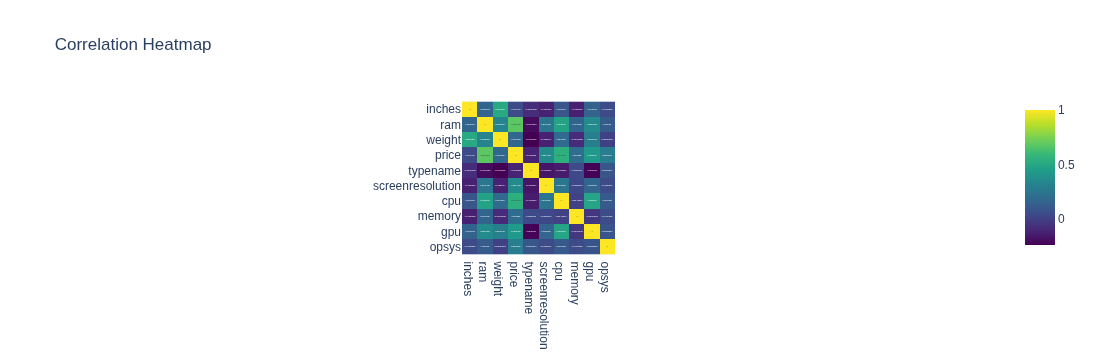

In [20]:
#Correlation Heatmap#
import plotly.express as px

corr = train_df.corr(numeric_only=True)

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='viridis',
    title="Correlation Heatmap"
)
fig.show()

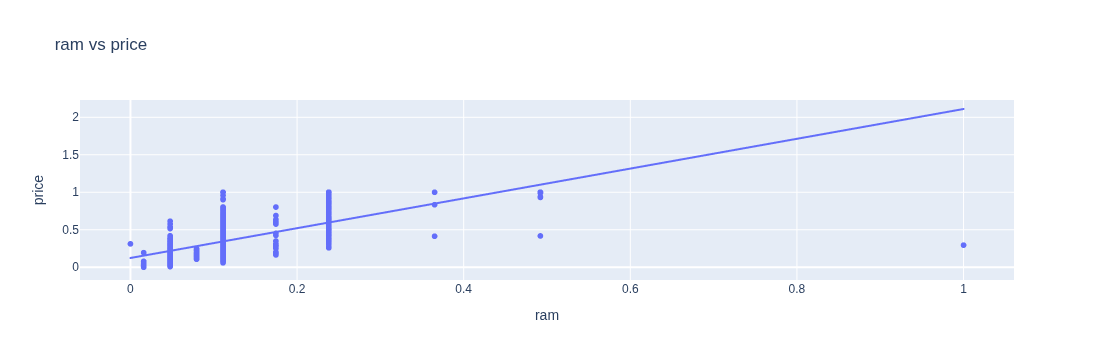

In [21]:
#Scatter plot + Regression Line#
import plotly.express as px

x_col = best_feature   
y_col = "price"

fig = px.scatter(
    train_df,
    x=x_col,
    y=y_col,
    trendline="ols",
    title=f"{x_col} vs {y_col}"
)
fig.show()

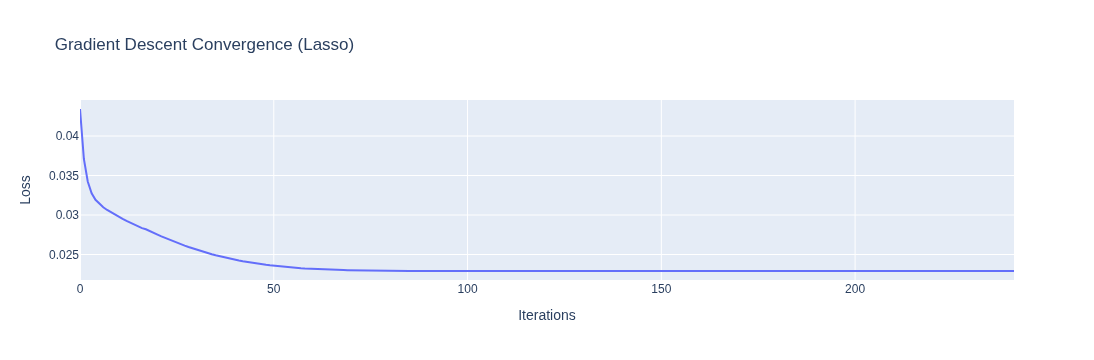

In [22]:
#Gradient Descent Convergence(Lasso)#
import plotly.graph_objects as go

model_lasso = fitted_models[('Full Model', 'Lasso')][0]

fig = go.Figure()
fig.add_trace(go.Scatter(
    y=model_lasso.loss_history,
    mode='lines',
    name='Loss'
))

fig.update_layout(
    title="Gradient Descent Convergence (Lasso)",
    xaxis_title="Iterations",
    yaxis_title="Loss"
)
fig.show()

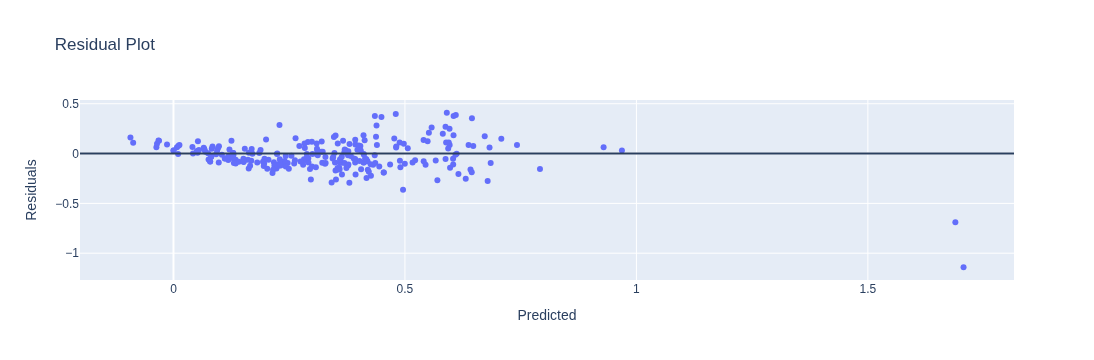

In [23]:
#Residel plot#
import plotly.express as px

model, features, X_test, y_test, y_pred = fitted_models[('Full Model', 'OLS')]

residuals = y_test - y_pred

fig = px.scatter(
    x=y_pred,
    y=residuals,
    labels={"x": "Predicted", "y": "Residuals"},
    title="Residual Plot"
)

fig.add_hline(y=0)
fig.show()

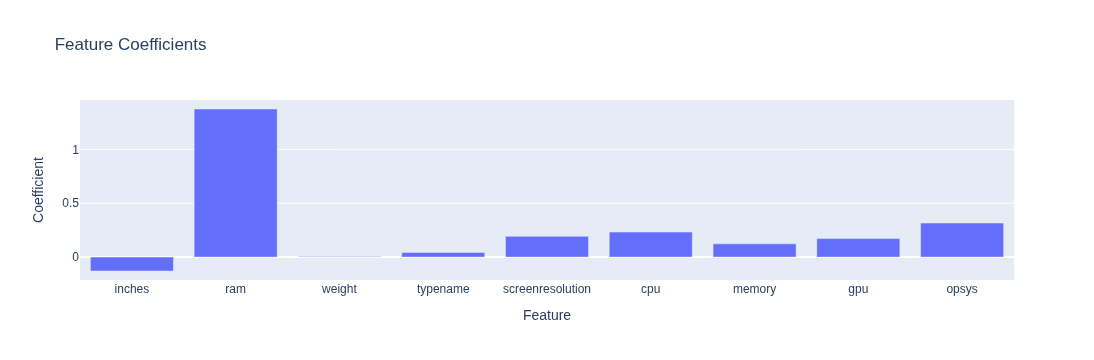

In [24]:
#Coefficient Bar Chart#
import plotly.express as px
import pandas as pd

model, features, _, _, _ = fitted_models[('Full Model', 'OLS')]

coef = model.beta[1:]  # نشيل intercept

df_coef = pd.DataFrame({
    "Feature": features,
    "Coefficient": coef
})

fig = px.bar(
    df_coef,
    x="Feature",
    y="Coefficient",
    title="Feature Coefficients"
)

fig.show()